In [226]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [227]:
subject_ids = range(27, 39)

# Only consider participants with win rate > 60% ("learners") like stated in the original paper:
# > As such, we applied the following a
# > priori criterion: only the data of participants who made a correct response on at least
# > 60% of the learnable trials in both the mid-value task and the high-value task were
# > included in the main EEG analysis

# https://github.com/chassall/averagetaskvalue/blob/main/analysis_05_makeerps.m#L33
# subject_ids = [27,28,31,34,35,36,37,38]

In [228]:
win_events = {
    "S  6": "win (low-task, low-cue)",
    "S 16": "win (mid-task, low-cue)",
    "S 26": "win (mid-task, high-cue)",
    "S 36": "win (high-task, high-cue)"
}
loss_events = {
    "S  7": "loss (low-task, low-cue)",
    "S 17": "loss (mid-task, low-cue)",
    "S 27": "loss (mid-task, high-cue)",
    "S 37": "loss (high-task, high-cue)"
}

# Read all preprocessed win/loss epochs of all subjects
all_epochs = []
win_epochs = []
win_epochs_dict = {}
loss_epochs = []
loss_epochs_dict = {}

for subject_id in subject_ids:
    for event in win_events.values():
        epochs = mne.read_epochs(f"fif-files/subject{subject_id}_feedback_{event.replace(' ', '-')}-epo.fif")
        epochs.set_eeg_reference(["TP9", "TP10"])

        if event not in win_epochs_dict:
            win_epochs_dict[event] = []

        win_epochs_dict[event].append(epochs)
        all_epochs.append(epochs)

    for event in loss_events.values():
        epochs = mne.read_epochs(f"fif-files/subject{subject_id}_feedback_{event.replace(' ', '-')}-epo.fif")
        epochs.set_eeg_reference(["TP9", "TP10"])

        if event not in loss_epochs_dict:
            loss_epochs_dict[event] = []

        loss_epochs_dict[event].append(epochs)
        all_epochs.append(epochs)

all_epochs_combined = mne.epochs.concatenate_epochs(all_epochs)
all_epochs_combined

Reading /home/mark/EEGproject/fif-files/subject27_feedback_win-(low-task,-low-cue)-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     600.00 ms
        0 CTF compensation matrices available
Not setting metadata
71 matching events found
No baseline correction applied
0 projection items activated
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Reading /home/mark/EEGproject/fif-files/subject27_feedback_win-(mid-task,-low-cue)-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     600.00 ms
        0 CTF compensation matrices available
Not setting metadata
34 matching events found
No baseline correction applied
0 projection items activated
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Reading /home/mark/EEGproject/fif-files/subject27_feedback_win-(mid-task,-high-cue)-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     600.00 ms
        0 CTF compensatio

/tmp/ipykernel_117086/1928472709.py:42: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  all_epochs_combined = mne.epochs.concatenate_epochs(all_epochs)


<EpochsArray | 4596 events (all good), -0.2 – 0.6 s (baseline -0.2 – 0 s), ~218.5 MB, data loaded,
 '6': 758
 '16': 393
 '26': 505
 '36': 934
 '7': 785
 '17': 364
 '27': 227
 '37': 630>

---
### Model #1 (bad model)


In [229]:
predictor_vars = [
    "intercept",
    "win (low-task, low-cue)",
    "win (mid-task, low-cue)",
    "win (mid-task, high-cue)",
    "win (high-task, high-cue)",
    "loss (low-task, low-cue)",
    "loss (mid-task, low-cue)",
    "loss (mid-task, high-cue)",
    "loss (high-task, high-cue)"
]

# Create the metadata from the epochs, then create the design matrix out of it

d = all_epochs_combined.to_data_frame(picks="FCz")

d['intercept'] = 1
# d['win/loss'] = d['condition'].apply(lambda x: 1 if x in ["6", "16", "26", "36"] else 0)
d['win (low-task, low-cue)'] = d['condition'].apply(lambda x: 1 if x == "6" else -1)
d['win (mid-task, low-cue)'] = d['condition'].apply(lambda x: 1 if x == "16" else -1)
d['win (mid-task, high-cue)'] = d['condition'].apply(lambda x: 1 if x == "26" else -1)
d['win (high-task, high-cue)'] = d['condition'].apply(lambda x: 1 if x == "36" else -1)
d['loss (low-task, low-cue)'] = d['condition'].apply(lambda x: 1 if x == "7" else -1)
d['loss (mid-task, low-cue)'] = d['condition'].apply(lambda x: 1 if x == "17" else -1)
d['loss (mid-task, high-cue)'] = d['condition'].apply(lambda x: 1 if x == "27" else -1)
d['loss (high-task, high-cue)'] = d['condition'].apply(lambda x: 1 if x == "37" else -1)

d = d.drop(["time", "FCz"], axis=1)
d = d.drop_duplicates()
all_epochs_combined.metadata = d


design_matrix = all_epochs_combined.metadata[predictor_vars]
# design_matrix["intercept"] = 1
design_matrix

Adding metadata with 11 columns


,intercept,"win (low-task, low-cue)","win (mid-task, low-cue)","win (mid-task, high-cue)","win (high-task, high-cue)","loss (low-task, low-cue)","loss (mid-task, low-cue)","loss (mid-task, high-cue)","loss (high-task, high-cue)"
6,1,1,-1,-1,-1,-1,-1,-1,-1
11,1,1,-1,-1,-1,-1,-1,-1,-1
31,1,1,-1,-1,-1,-1,-1,-1,-1
36,1,1,-1,-1,-1,-1,-1,-1,-1
41,1,1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...
202155,1,-1,-1,-1,-1,-1,-1,-1,1
202185,1,-1,-1,-1,-1,-1,-1,-1,1
202190,1,-1,-1,-1,-1,-1,-1,-1,1
202195,1,-1,-1,-1,-1,-1,-1,-1,1


---
### Model 1 (good): low-low vs mid-low

In [230]:

predictor_vars = [
    "intercept",
    "win/loss", 
    "(low-task, low-cue)",
    "(mid-task, low-cue)",
]

# Create the metadata from the epochs, then create the design matrix out of it
d = all_epochs_combined.to_data_frame(picks="FCz")

d['intercept'] = 1
d['win/loss'] = d['condition'].apply(lambda x: 1 if x in ["6", "16", "26", "36"] else -1)
d['(low-task, low-cue)'] = d['condition'].apply(lambda x: 1 if x in ["6", "7"] else -1)
d['(mid-task, low-cue)'] = d['condition'].apply(lambda x: 1 if x in ["16", "17"] else -1)

d = d.drop(["time", "FCz"], axis=1)
d = d.drop_duplicates()
all_epochs_combined.metadata = d

design_matrix = all_epochs_combined.metadata[predictor_vars]
design_matrix

Replacing existing metadata with 6 columns


,intercept,win/loss,"(low-task, low-cue)","(mid-task, low-cue)"
6,1,1,1,-1
11,1,1,1,-1
31,1,1,1,-1
36,1,1,1,-1
41,1,1,1,-1
...,...,...,...,...
202155,1,-1,-1,-1
202185,1,-1,-1,-1
202190,1,-1,-1,-1
202195,1,-1,-1,-1


In [231]:
reg = mne.stats.linear_regression(all_epochs_combined, design_matrix=design_matrix, names=predictor_vars)
print("predictors are:", list(reg))

Fitting linear model to epochs, (6231 targets, 4 regressors)
Done
predictors are: ['intercept', 'win/loss', '(low-task, low-cue)', '(mid-task, low-cue)']


No projector specified for this dataset. Please consider the method self.add_proj.


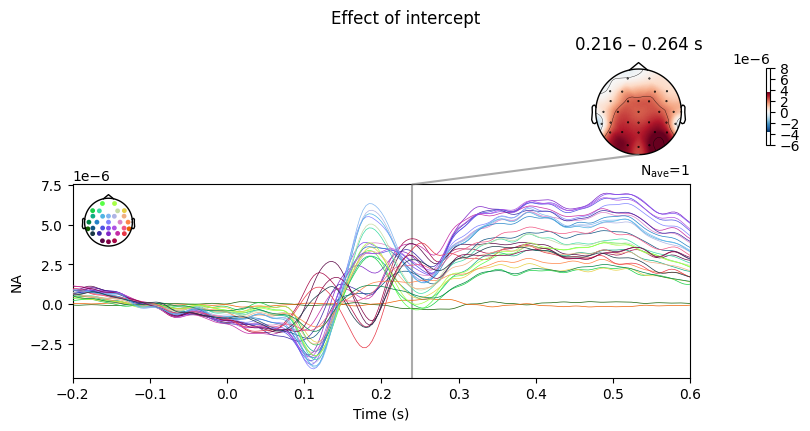

No projector specified for this dataset. Please consider the method self.add_proj.


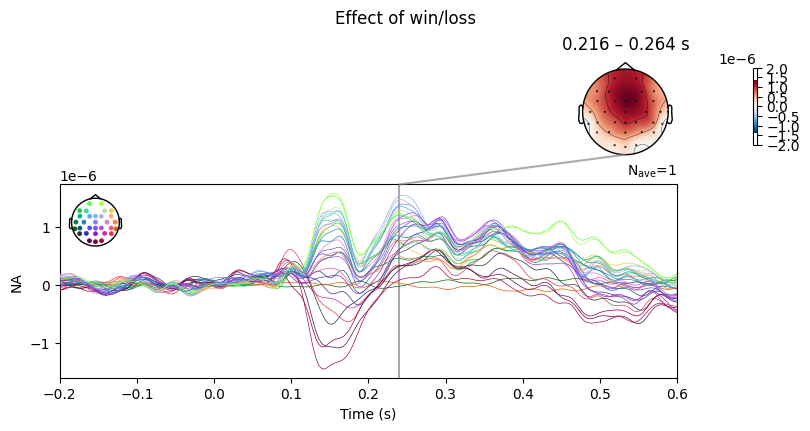

No projector specified for this dataset. Please consider the method self.add_proj.


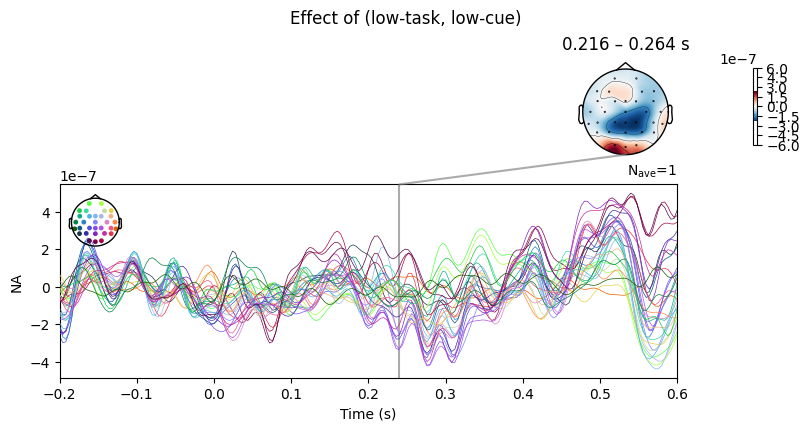

No projector specified for this dataset. Please consider the method self.add_proj.


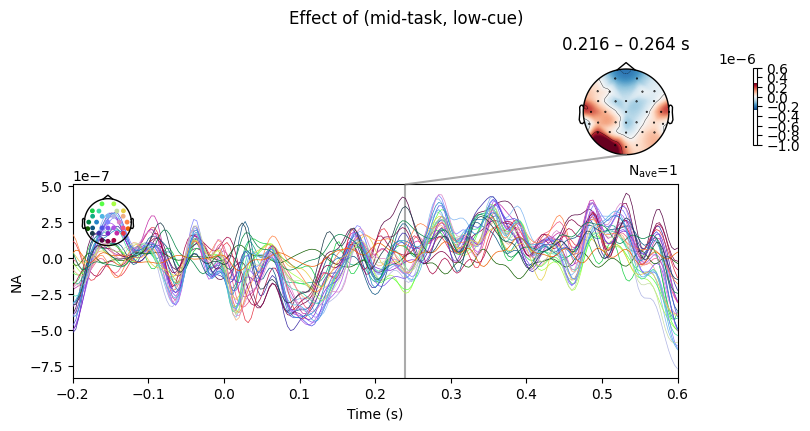

In [232]:
ts_args = dict(xlim=(-0.2, 0.6), unit=False)
topomap_args = dict(scalings=dict(eeg=1), average=0.05)
for cond in predictor_vars:
    reg[cond].beta.plot_joint(
        ts_args=ts_args, topomap_args=topomap_args, title=f"Effect of {cond}", times=[0.24]
    )

---
### Model #2 - mid-high vs high-high

In [233]:
all_epochs_combined = mne.epochs.concatenate_epochs(all_epochs)

predictor_vars = [
    "intercept",
    "win/loss",
    "(mid-task, high-cue)",
    "(high-task, high-cue)"
]

# Create the metadata from the epochs, then create the design matrix out of it
d = all_epochs_combined.to_data_frame(picks="FCz")

d['intercept'] = 1
d['win/loss'] = d['condition'].apply(lambda x: 1 if x in ["6", "16", "26", "36"] else -1)
d['(mid-task, high-cue)'] = d['condition'].apply(lambda x: 1 if x in ["26", "27"] else -1)
d['(high-task, high-cue)'] = d['condition'].apply(lambda x: 1 if x in ["36", "37"] else -1)

d = d.drop(["time", "FCz"], axis=1)
d = d.drop_duplicates()
all_epochs_combined.metadata = d

design_matrix = all_epochs_combined.metadata[predictor_vars]
design_matrix

Not setting metadata
4596 matching events found
Applying baseline correction (mode: mean)


/tmp/ipykernel_117086/585826616.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  all_epochs_combined = mne.epochs.concatenate_epochs(all_epochs)


Adding metadata with 6 columns


,intercept,win/loss,"(mid-task, high-cue)","(high-task, high-cue)"
6,1,1,-1,-1
11,1,1,-1,-1
31,1,1,-1,-1
36,1,1,-1,-1
41,1,1,-1,-1
...,...,...,...,...
202155,1,-1,-1,1
202185,1,-1,-1,1
202190,1,-1,-1,1
202195,1,-1,-1,1


In [234]:
reg = mne.stats.linear_regression(all_epochs_combined, design_matrix=design_matrix, names=predictor_vars)
print("predictors are:", list(reg))

Fitting linear model to epochs, (6231 targets, 4 regressors)
Done
predictors are: ['intercept', 'win/loss', '(mid-task, high-cue)', '(high-task, high-cue)']


No projector specified for this dataset. Please consider the method self.add_proj.


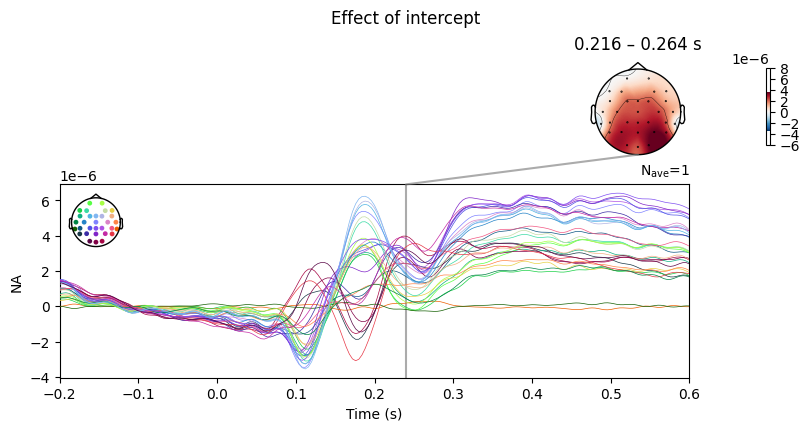

No projector specified for this dataset. Please consider the method self.add_proj.


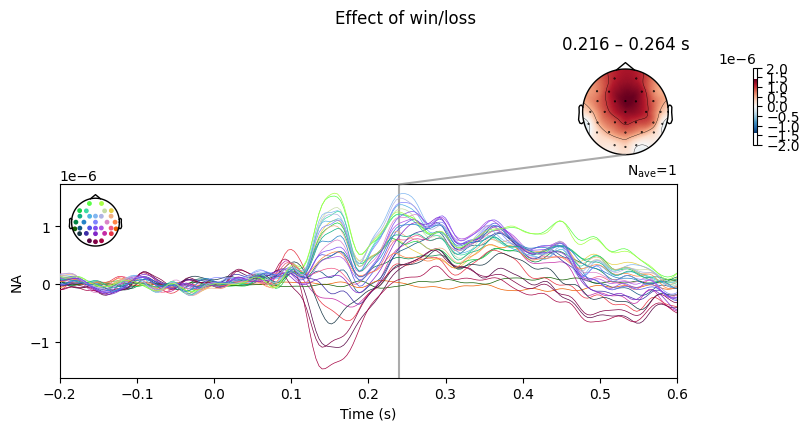

No projector specified for this dataset. Please consider the method self.add_proj.


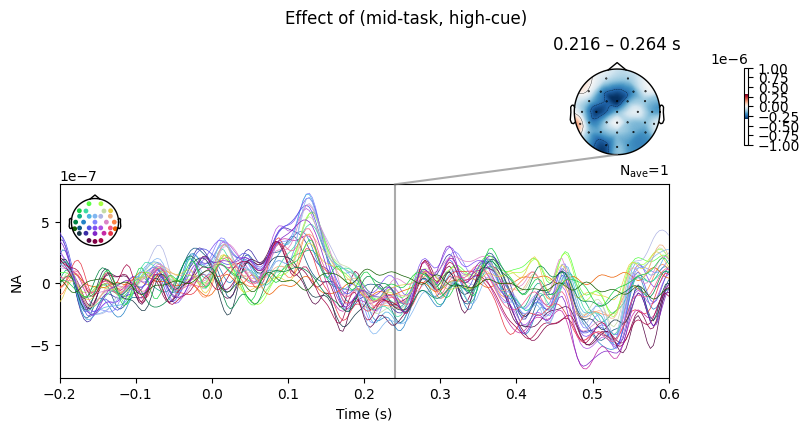

No projector specified for this dataset. Please consider the method self.add_proj.


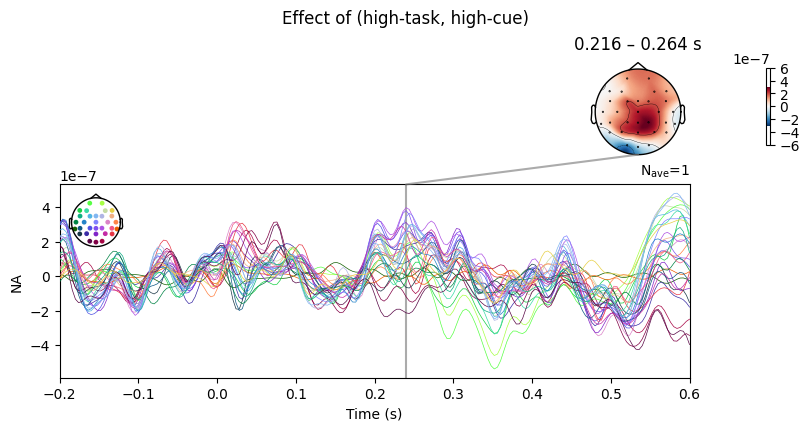

In [235]:
ts_args = dict(xlim=(-0.2, 0.6), unit=False)
topomap_args = dict(scalings=dict(eeg=1), average=0.05)
for cond in predictor_vars:
    reg[cond].beta.plot_joint(
        ts_args=ts_args, topomap_args=topomap_args, title=f"Effect of {cond}", times=[0.24]
    )